In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
from ultralytics import YOLO
from scipy.optimize import minimize, least_squares
from scipy.spatial.distance import cdist
import torch
import warnings
warnings.filterwarnings('ignore')

print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Device: CPU


In [2]:
# Paths
PROJECT_ROOT = Path.cwd()

PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

MODEL_PATH   = (PROJECT_ROOT / "data" / "runs" / "final_model"
                / "all_data_deployment" / "weights" / "best.pt")

IMAGE_PATHS = {
    # Used for weight derivation
    'weight_derivation': [
        PROJECT_ROOT / "data" / "test_images" / f"distorted{i}.{ext}"
        for i, ext in [
            (21, 'webp'),
            (22, 'png'), (23, 'png'), (24, 'png'), (25, 'png'),
            (26, 'png'), (27, 'png'), (28, 'png'), (29, 'png'), (30, 'png'),
        ]
    ],
    # Used for Powell optimisation, correction figures, and discrimination stats
    'distorted': [
        PROJECT_ROOT / "data" / "test_images" / f"distorted{i}.{ext}"
        for i, ext in [
            (1,'jpeg'),(2,'webp'),(3,'png'),(4,'png'),(5,'png'),
            (6,'webp'),(7,'png'),(8,'webp'),(9,'png'),(10,'png'),
            (11,'jpeg'),(12,'webp'),(13,'png'),(14,'png'),(15,'png'),
            (16,'webp'),(17,'jpeg'),(18,'webp'),(19,'png'),(20,'png'),
        ]
    ],
    # Used for discrimination stats only
    'straight': [
        PROJECT_ROOT / "data" / "test_images" / f"straight{i}.{ext}"
        for i, ext in [
            (1,'webp'),(2,'png'),(3,'png'),(4,'png'),(5,'webp'),
            (6,'webp'),(7,'png'),(8,'png'),(9,'png'),(10,'webp'),
            (11,'webp'),(12,'png'),(13,'webp'),(14,'png'),(15,'png'),
            (16,'png'),(17,'png'),(18,'png'),(19,'webp'),(20,'png'),
        ]
    ],
}

N_WEIGHT = len(IMAGE_PATHS['weight_derivation'])
N_DIST   = len(IMAGE_PATHS['distorted'])
N_STR    = len(IMAGE_PATHS['straight'])
print(f"Weight derivation: {N_WEIGHT} images  |  "
      f"Distorted: {N_DIST}  |  Straight: {N_STR}")

model = YOLO(MODEL_PATH)

# Homography constants
# h3 (index 2) and h6 (index 5) are translation parameters.
# They don't affect wheel shape, relative size, or relative vertical position,
# so they are fixed at their identity values — see thesis Section 3.2.1.
IDENTITY_VALS = np.array([1, 0, 0, 0, 1, 0, 0, 0], dtype=np.float64)
FREE_INDICES  = [0, 1, 3, 4, 6, 7]   # h1, h2, h4, h5, h7, h8
X0            = IDENTITY_VALS[FREE_INDICES]

plt.rcParams.update({
    "text.usetex":       True,
    "font.family":       "serif",
    "font.serif":        ["Computer Modern"],
    "font.size":         11,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   9,
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
RED  = '#d6604d'
BLUE = '#2166ac'
GREY = '#888888'

Weight derivation: 10 images  |  Distorted: 20  |  Straight: 20


In [3]:
# Helper Functions

def load_image(path):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Could not load: {path}")
    return img


def sample_ellipse_points(ellipse, n_points=100):
    """Return n_points evenly spaced along an OpenCV ellipse."""
    (cx, cy), (w, h), angle = ellipse
    a, b = w / 2, h / 2
    t    = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    ar   = np.deg2rad(angle)
    x = a * np.cos(t) * np.cos(ar) - b * np.sin(t) * np.sin(ar) + cx
    y = a * np.cos(t) * np.sin(ar) + b * np.sin(t) * np.cos(ar) + cy
    return np.column_stack([x, y])


def ellipse_metrics(ellipse):
    """Centre, mean radius, and aspect ratio (minor/major) of an OpenCV ellipse."""
    (cx, cy), (w, h), _ = ellipse
    a, b = max(w, h) / 2, min(w, h) / 2
    return {
        'center':       np.array([cx, cy]),
        'radius':       (a + b) / 2,
        'aspect_ratio': b / a if a > 0 else 1.0,
    }


def fit_ellipse_to_points(points):
    pts = points.astype(np.float32).reshape(-1, 1, 2)
    return cv2.fitEllipse(pts) if len(pts) >= 5 else None


def build_H(free_params):
    """Assemble 3×3 homography from the six free parameters."""
    h = IDENTITY_VALS.copy()
    for idx, val in zip(FREE_INDICES, free_params):
        h[idx] = val
    return np.array([[h[0], h[1], h[2]],
                     [h[3], h[4], h[5]],
                     [h[6], h[7], 1.0]])


def transform_points(points, H):
    ph = np.column_stack([points, np.ones(len(points))])
    tr = (H @ ph.T).T
    return tr[:, :2] / (tr[:, 2:] + 1e-10)


def apply_homography_for_display(image, H):
    """Warp the full frame and shift so the result sits at (0, 0)."""
    h, w     = image.shape[:2]
    corners  = np.array([[0,0],[w,0],[w,h],[0,h]], dtype=np.float32)
    tc       = transform_points(corners, H)
    min_x, min_y = tc.min(axis=0)
    max_x, max_y = tc.max(axis=0)
    H_shift   = np.array([[1, 0, -min_x], [0, 1, -min_y], [0, 0, 1]])
    H_adj     = H_shift @ H
    corrected = cv2.warpPerspective(
        image, H_adj,
        (int(max_x - min_x), int(max_y - min_y)),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(255, 255, 255),
    )
    return corrected, H_adj


def compute_loss_terms(free_params, ellipses, img_shape):
    """
    Evaluate the three geometric loss terms given free homography parameters.
    Returns a dict of {L_circ, L_radius, L_align, m1, m2} or None on failure.
    """
    H   = build_H(free_params)
    det = np.linalg.det(H)
    if det <= 0 or det > 1e8:
        return None
    metrics_list = []
    for ellipse in ellipses:
        pts = sample_ellipse_points(ellipse, n_points=100)
        tr  = transform_points(pts, H)
        if np.any(np.abs(tr) > img_shape[1] * 10):
            return None
        ne = fit_ellipse_to_points(tr)
        if ne is None:
            return None
        metrics_list.append(ellipse_metrics(ne))
    m1, m2      = metrics_list
    mean_radius = (m1['radius'] + m2['radius']) / 2 + 1e-6
    return {
        'L_circ':   (1 - m1['aspect_ratio'])**2 + (1 - m2['aspect_ratio'])**2,
        'L_radius': ((m1['radius'] - m2['radius']) / mean_radius)**2,
        'L_align':  ((m1['center'][1] - m2['center'][1]) / mean_radius)**2,
        'm1': m1, 'm2': m2,
    }


def constrained_loss(free_params, ellipses, img_shape, weights):
    """Weighted sum of the three geometric loss terms."""
    terms = compute_loss_terms(free_params, ellipses, img_shape)
    if terms is None:
        return 1e10
    w1, w2, w3 = weights
    return w1 * terms['L_circ'] + w2 * terms['L_radius'] + w3 * terms['L_align']


def constrained_residuals(free_params, ellipses, img_shape, weights):
    """Square-root residuals for scipy least_squares (TRF comparison only)."""
    H   = build_H(free_params)
    det = np.linalg.det(H)
    if det <= 0 or det > 1e8:
        return np.ones(4) * 1e5
    metrics_list = []
    for ellipse in ellipses:
        pts = sample_ellipse_points(ellipse, n_points=100)
        tr  = transform_points(pts, H)
        if np.any(np.abs(tr) > img_shape[1] * 10):
            return np.ones(4) * 1e5
        ne = fit_ellipse_to_points(tr)
        if ne is None:
            return np.ones(4) * 1e5
        metrics_list.append(ellipse_metrics(ne))
    m1, m2      = metrics_list
    mean_radius = (m1['radius'] + m2['radius']) / 2 + 1e-6
    w1, w2, w3  = weights
    return np.array([
        np.sqrt(w1) * (1 - m1['aspect_ratio']),
        np.sqrt(w1) * (1 - m2['aspect_ratio']),
        np.sqrt(w2) * (m1['radius'] - m2['radius']) / mean_radius,
        np.sqrt(w3) * (m1['center'][1] - m2['center'][1]) / mean_radius,
    ])


THUMB = 240

def make_wheel_thumb(img_bgr, ellipses, transform=None,
                     color='yellow', size=THUMB, fill=0.88):
    all_pts = np.vstack([
        (transform_points(sample_ellipse_points(e, 100), transform)
         if transform is not None
         else sample_ellipse_points(e, 100))
        for e in ellipses
    ])
    cx   = (all_pts[:, 0].min() + all_pts[:, 0].max()) / 2
    cy   = (all_pts[:, 1].min() + all_pts[:, 1].max()) / 2
    side = max(all_pts[:, 0].max() - all_pts[:, 0].min(),
               all_pts[:, 1].max() - all_pts[:, 1].min()) / fill
    cy  -= 0.2 * side

    h, w  = img_bgr.shape[:2]
    x0 = int(cx - side / 2); y0 = int(cy - side / 2)
    x1 = int(cx + side / 2); y1 = int(cy + side / 2)

    # Save crop origin in source coordinate space BEFORE the padding adjustment.
    # These are used to map ellipse points into crop pixel space.
    # After padding, x0/y0 shift by pad_l/pad_t — if we subtracted the shifted
    # values from the (unshifted) ellipse points the overlays would be offset
    # by exactly the padding amount.
    x0_src, y0_src = x0, y0

    pad_l = max(0, -x0); pad_t = max(0, -y0)
    pad_r = max(0, x1 - w); pad_b = max(0, y1 - h)
    if any([pad_l, pad_t, pad_r, pad_b]):
        img_bgr = cv2.copyMakeBorder(img_bgr, pad_t, pad_b, pad_l, pad_r,
                                     cv2.BORDER_CONSTANT, value=(255, 255, 255))
        x0 += pad_l; y0 += pad_t; x1 += pad_l; y1 += pad_t

    # Separate x/y scales — integer rounding means the crop is not always
    # exactly square, so a single scale applied to both axes can misplace overlays.
    scale_x = size / (x1 - x0)
    scale_y = size / (y1 - y0)

    thumb     = cv2.resize(img_bgr[y0:y1, x0:x1], (size, size),
                           interpolation=cv2.INTER_AREA)
    thumb_rgb = cv2.cvtColor(thumb, cv2.COLOR_BGR2RGB)

    fig_tmp, ax_tmp = plt.subplots(figsize=(size/100, size/100), dpi=100)
    ax_tmp.imshow(thumb_rgb)
    ax_tmp.set_xlim(0, size); ax_tmp.set_ylim(size, 0); ax_tmp.axis('off')
    for e in ellipses:
        pts = sample_ellipse_points(e, 160)
        if transform is not None:
            pts = transform_points(pts, transform)
        ax_tmp.plot((pts[:, 0] - x0_src) * scale_x,
                    (pts[:, 1] - y0_src) * scale_y,
                    color=color, linewidth=1.5)
    fig_tmp.subplots_adjust(0, 0, 1, 1)
    fig_tmp.canvas.draw()
    buf = np.asarray(fig_tmp.canvas.buffer_rgba())[:, :, :3].copy()
    plt.close(fig_tmp)
    return cv2.resize(buf, (size, size), interpolation=cv2.INTER_AREA)

In [4]:
# Wheel Detection

def detect_wheels(image):
    """
    Return (list_of_two_ellipses, error_string_or_None).
    Ellipses are sorted left-to-right (front wheel first).
    """
    results = model(image, verbose=False)[0]
    if results.masks is None:
        return None, "No masks detected"

    ellipses = []
    for mask in results.masks.data.cpu().numpy():
        mr  = cv2.resize(mask, (image.shape[1], image.shape[0]))
        mu8 = (mr * 255).astype(np.uint8)
        contours, _ = cv2.findContours(mu8, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        lg = max(contours, key=cv2.contourArea)
        if len(lg) < 5:
            continue
        ellipse = cv2.fitEllipse(lg)
        x, y, bw, bh = cv2.boundingRect(lg)
        touches = (x <= 1 or y <= 1 or
                   x + bw >= image.shape[1] - 1 or
                   y + bh >= image.shape[0] - 1)
        pts     = sample_ellipse_points(ellipse, 100)
        fit_err = cdist(lg.reshape(-1, 2), pts).min(axis=1).mean()
        ellipses.append({'ellipse': ellipse,
                         'touches_edge': touches,
                         'fit_error': fit_err})

    if len(ellipses) < 2:
        return None, f"Only {len(ellipses)} wheel(s) detected"

    ellipses = sorted(ellipses,
                      key=lambda e: e['ellipse'][1][0] * e['ellipse'][1][1],
                      reverse=True)[:2]
    ellipses = sorted(ellipses, key=lambda e: e['ellipse'][0][0])
    return [e['ellipse'] for e in ellipses], None


# Detect wheels for every image in every set and cache results
all_data = {}
for category, paths in IMAGE_PATHS.items():
    for i, path in enumerate(paths, start=1):
        key           = f"{category}_{i}"
        image         = load_image(path)
        ellipses, err = detect_wheels(image)
        all_data[key] = {
            'image':    image,
            'category': category,
            'ellipses': ellipses,
            'error':    err,
        }
        status = "OK" if ellipses else f"FAILED: {err}"
        print(f"  {key}: {status}")


  weight_derivation_1: OK
  weight_derivation_2: OK
  weight_derivation_3: OK
  weight_derivation_4: OK
  weight_derivation_5: OK
  weight_derivation_6: OK
  weight_derivation_7: OK
  weight_derivation_8: OK
  weight_derivation_9: OK
  weight_derivation_10: OK
  distorted_1: OK
  distorted_2: OK
  distorted_3: OK
  distorted_4: OK
  distorted_5: OK
  distorted_6: OK
  distorted_7: OK
  distorted_8: OK
  distorted_9: OK
  distorted_10: OK
  distorted_11: OK
  distorted_12: OK
  distorted_13: OK
  distorted_14: OK
  distorted_15: OK
  distorted_16: OK
  distorted_17: OK
  distorted_18: OK
  distorted_19: OK
  distorted_20: OK
  straight_1: OK
  straight_2: OK
  straight_3: OK
  straight_4: OK
  straight_5: OK
  straight_6: OK
  straight_7: OK
  straight_8: OK
  straight_9: OK
  straight_10: OK
  straight_11: OK
  straight_12: OK
  straight_13: OK
  straight_14: OK
  straight_15: OK
  straight_16: OK
  straight_17: OK
  straight_18: OK
  straight_19: OK
  straight_20: OK


In [5]:
# Weight Derivation

# Weights are set inversely proportional to the mean magnitude of each loss
# term at the identity transformation, then normalised to sum to one, so that
# all three terms contribute equally before optimisation begins.

circ_vals, radius_vals, align_vals = [], [], []

for i in range(1, N_WEIGHT + 1):
    d = all_data[f"weight_derivation_{i}"]
    if not d['ellipses']:
        print(f"  weight_derivation_{i}: skipped (no wheels detected)")
        continue
    t = compute_loss_terms(X0, d['ellipses'], d['image'].shape)
    if t is None:
        print(f"  weight_derivation_{i}: skipped (loss evaluation failed)")
        continue
    circ_vals.append(t['L_circ'])
    radius_vals.append(t['L_radius'])
    align_vals.append(t['L_align'])

assert len(circ_vals) > 0, \
    "No weight derivation images produced valid loss terms — check detections."

means   = np.array([np.mean(circ_vals), np.mean(radius_vals), np.mean(align_vals)])
raw_w   = 1.0 / (means + 1e-30)
WEIGHTS = tuple(raw_w / raw_w.sum())

print(f"Weight derivation: {len(circ_vals)}/{N_WEIGHT} images used")
print(f"Mean loss magnitudes at identity:")
print(f"  L_circ   = {means[0]:.6f}")
print(f"  L_radius = {means[1]:.6f}")
print(f"  L_align  = {means[2]:.6f}")
print(f"\nDerived weights:")
print(f"  w_circ={WEIGHTS[0]:.3f},  w_radius={WEIGHTS[1]:.3f},  w_align={WEIGHTS[2]:.3f}")

Weight derivation: 10/10 images used
Mean loss magnitudes at identity:
  L_circ   = 0.128497
  L_radius = 0.071503
  L_align  = 0.625533

Derived weights:
  w_circ=0.333,  w_radius=0.599,  w_align=0.068


In [6]:
# Loss at Identity — Evaluation Images

# Computes L_total at the identity transformation for distorted1–20 and
# straight1–20.  Used for the discrimination statistics and to rank distorted
# images for the correction pairs figure.

for category, n in [('distorted', N_DIST), ('straight', N_STR)]:
    for i in range(1, n + 1):
        key = f"{category}_{i}"
        d   = all_data[key]
        if not d['ellipses']:
            d['L_identity'] = None
            continue
        t = compute_loss_terms(X0, d['ellipses'], d['image'].shape)
        if t is None:
            d['L_identity'] = None
            continue
        w1, w2, w3 = WEIGHTS
        d['L_identity'] = (w1 * t['L_circ']
                           + w2 * t['L_radius']
                           + w3 * t['L_align'])

dist_losses = np.array([all_data[f"distorted_{i}"]['L_identity']
                         for i in range(1, N_DIST + 1)
                         if all_data[f"distorted_{i}"]['L_identity'] is not None])
str_losses  = np.array([all_data[f"straight_{i}"]['L_identity']
                         for i in range(1, N_STR + 1)
                         if all_data[f"straight_{i}"]['L_identity'] is not None])

print(f"Distorted  — n={len(dist_losses)},  mean={dist_losses.mean():.4f},  "
      f"min={dist_losses.min():.4f},  max={dist_losses.max():.4f}")
print(f"Straight   — n={len(str_losses)},  mean={str_losses.mean():.4f},  "
      f"min={str_losses.min():.4f},  max={str_losses.max():.4f}")
print(f"Ratio of means: {dist_losses.mean() / str_losses.mean():.1f}x")
print(f"Complete separation: {dist_losses.min() > str_losses.max()}")

Distorted  — n=20,  mean=0.0282,  min=0.0072,  max=0.1175
Straight   — n=20,  mean=0.0034,  min=0.0002,  max=0.0160
Ratio of means: 8.4x
Complete separation: False


In [7]:
# Powell Optimisation — Distorted Images

powell_results = {}

for i in range(1, N_DIST + 1):
    key = f"distorted_{i}"
    d   = all_data[key]
    if not d['ellipses']:
        continue
    res = minimize(
        constrained_loss,
        X0,
        args=(d['ellipses'], d['image'].shape, WEIGHTS),
        method='Powell',
        options={'maxiter': 10000, 'ftol': 1e-12, 'xtol': 1e-12},
    )
    powell_results[key] = {'x': res.x, 'loss': res.fun, 'nfev': res.nfev}
    print(f"  {key}: loss {d['L_identity']:.4f} → {res.fun:.6f}  (nfev={res.nfev})")

  distorted_1: loss 0.0209 → 0.001008  (nfev=4196)
  distorted_2: loss 0.0077 → 0.000027  (nfev=3263)
  distorted_3: loss 0.0656 → 0.001043  (nfev=3154)
  distorted_4: loss 0.0197 → 0.000344  (nfev=3155)
  distorted_5: loss 0.0101 → 0.000002  (nfev=5123)
  distorted_6: loss 0.0267 → 0.000032  (nfev=3583)
  distorted_7: loss 0.0160 → 0.000099  (nfev=3635)
  distorted_8: loss 0.0492 → 0.000491  (nfev=3129)
  distorted_9: loss 0.0319 → 0.000509  (nfev=2849)
  distorted_10: loss 0.0487 → 0.007544  (nfev=2949)
  distorted_11: loss 0.0187 → 0.000004  (nfev=3963)
  distorted_12: loss 0.1175 → 0.000291  (nfev=4170)
  distorted_13: loss 0.0072 → 0.000014  (nfev=3494)
  distorted_14: loss 0.0134 → 0.001779  (nfev=4253)
  distorted_15: loss 0.0129 → 0.000191  (nfev=3351)
  distorted_16: loss 0.0079 → 0.000015  (nfev=3242)
  distorted_17: loss 0.0165 → 0.000352  (nfev=3392)
  distorted_18: loss 0.0311 → 0.000003  (nfev=3173)
  distorted_19: loss 0.0207 → 0.001932  (nfev=3774)
  distorted_20: loss 

In [8]:
# Powell vs TRF — Algorithm Selection

X_SCALE = np.array([0.3, 0.3, 0.3, 0.3, 0.005, 0.005])

print("Powell vs TRF — identical loss, identical initialisation")
print(f"{'Image':<14} {'Powell':>10} {'TRF':>10} {'Ratio':>8}  "
      f"{'Powell nfev':>12}  {'TRF nfev':>10}")
print("-" * 68)

trf_results = {}
for i in range(1, N_DIST + 1):
    key = f"distorted_{i}"
    d   = all_data[key]
    if not d['ellipses'] or key not in powell_results:
        continue
    res_t = least_squares(
        constrained_residuals,
        X0,
        args=(d['ellipses'], d['image'].shape, WEIGHTS),
        method='trf',
        x_scale=X_SCALE,
        ftol=1e-12, xtol=1e-12, gtol=1e-12,
        max_nfev=50000,
    )
    trf_loss         = 2 * res_t.cost
    trf_results[key] = {'loss': trf_loss, 'nfev': res_t.nfev}
    ratio            = trf_loss / (powell_results[key]['loss'] + 1e-30)
    print(f"{key:<14} {powell_results[key]['loss']:>10.6f} {trf_loss:>10.6f} "
          f"{ratio:>8.2f}  {powell_results[key]['nfev']:>12}  {res_t.nfev:>10}")

ratios      = [trf_results[k]['loss'] / (powell_results[k]['loss'] + 1e-30)
               for k in trf_results]
powell_nfev = [powell_results[k]['nfev'] for k in trf_results]
trf_nfev    = [trf_results[k]['nfev']    for k in trf_results]

print(f"\nPowell wins: {sum(1 for r in ratios if r > 1)}/{len(ratios)}")
print(f"TRF / Powell loss ratio:  min={min(ratios):.2f}x,  max={max(ratios):.2f}x")
print(f"Powell nfev range: {min(powell_nfev)}–{max(powell_nfev)}")
print(f"TRF    nfev range: {min(trf_nfev)}–{max(trf_nfev)}")

Powell vs TRF — identical loss, identical initialisation
Image              Powell        TRF    Ratio   Powell nfev    TRF nfev
--------------------------------------------------------------------
distorted_1      0.001008   0.005898     5.85          4196          28
distorted_2      0.000027   0.000740    27.86          3263          28
distorted_3      0.001043   0.022693    21.76          3154          26
distorted_4      0.000344   0.006894    20.04          3155          28
distorted_5      0.000002   0.005010  2153.41          5123          29
distorted_6      0.000032   0.006151   192.54          3583          30
distorted_7      0.000099   0.002142    21.63          3635          30
distorted_8      0.000491   0.007110    14.48          3129          29
distorted_9      0.000509   0.009784    19.22          2849          24
distorted_10     0.007544   0.018452     2.45          2949          26
distorted_11     0.000004   0.001099   265.41          3963          24
distorted_

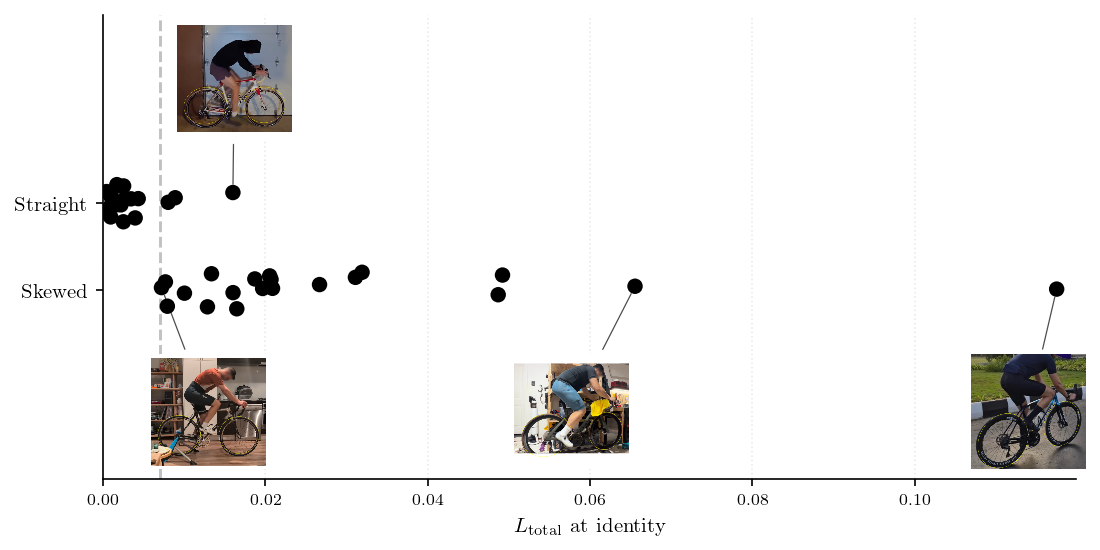

Distorted mean=0.0282,  Straight mean=0.0034,  Ratio=8.4x,  Complete separation=False


In [15]:
# Figure 1 — Loss Discrimination

dist_keys = [f"distorted_{i}" for i in range(1, N_DIST + 1)
             if all_data[f"distorted_{i}"]['L_identity'] is not None]
str_keys  = [f"straight_{i}"  for i in range(1, N_STR + 1)
             if all_data[f"straight_{i}"]['L_identity']  is not None]

d_losses = np.array([all_data[k]['L_identity'] for k in dist_keys])
s_losses = np.array([all_data[k]['L_identity'] for k in str_keys])

ROW_STR    =  0.18
ROW_SKW    =  0.00
IMG_OFFSET =  0.25
MARGIN     =  0.14

np.random.seed(0)
y_d = ROW_SKW + np.random.uniform(-0.04, 0.04, len(d_losses))
y_s = ROW_STR + np.random.uniform(-0.04, 0.04, len(s_losses))

d_sorted   = np.argsort(d_losses)[::-1]
thumb_keys = [
    dist_keys[d_sorted[0]],
    dist_keys[d_sorted[1]],
    dist_keys[d_sorted[-1]],
    str_keys[np.argmax(s_losses)],
]
thumb_xy = [
    (d_losses[d_sorted[0]],  y_d[d_sorted[0]]),
    (d_losses[d_sorted[1]],  y_d[d_sorted[1]]),
    (d_losses[d_sorted[-1]], y_d[d_sorted[-1]]),
    (s_losses[np.argmax(s_losses)], y_s[np.argmax(s_losses)]),
]
thumb_xybox = [
    (d_losses[d_sorted[0]]  * 0.97, ROW_SKW - IMG_OFFSET),
    (d_losses[d_sorted[1]]  * 0.88, ROW_SKW - IMG_OFFSET),
    (d_losses[d_sorted[-1]] * 1.80, ROW_SKW - IMG_OFFSET),
    (s_losses[np.argmax(s_losses)] * 1.01, ROW_STR + IMG_OFFSET),
]


def add_thumb(ax, key, xy, xybox):
    d   = all_data[key]
    img = make_wheel_thumb(d['image'], d['ellipses'],
                           color='yellow', size=600, fill=0.88)
    ax.add_artist(AnnotationBbox(
        OffsetImage(img, zoom=0.092),
        xy, xybox=xybox,
        xycoords='data', boxcoords='data',
        frameon=False, pad=0.0,
        arrowprops=dict(arrowstyle='-', color='0.3',
                        linewidth=0.6, shrinkA=2, shrinkB=4),
    ))


fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.scatter(d_losses, y_d, color='black', s=55, zorder=4, alpha=1.0, edgecolors='none')
ax.scatter(s_losses, y_s, color='black', s=55, zorder=4, alpha=1.0, edgecolors='none')
ax.axvline(d_losses[d_sorted[-1]] * 0.98,
           color='0.4', linestyle='--', linewidth=1.4, alpha=0.4)

ax.set_yticks([ROW_SKW, ROW_STR])
ax.set_yticklabels(['Skewed', 'Straight'], fontsize=10)
ax.set_xlabel('$L_{\\mathrm{total}}$ at identity')
ax.set_xlim(0, max(d_losses.max(), s_losses.max()) * 1.02)
ax.set_ylim(ROW_SKW - IMG_OFFSET - MARGIN, ROW_STR + IMG_OFFSET + MARGIN)

for key, xy, xybox in zip(thumb_keys, thumb_xy, thumb_xybox):
    add_thumb(ax, key, xy, xybox)

ax.grid(axis='x', alpha=0.25, linestyle=':')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig_loss_discrimination.pdf', bbox_inches='tight', dpi=250)
plt.show()

print(f"Distorted mean={d_losses.mean():.4f},  Straight mean={s_losses.mean():.4f},  "
      f"Ratio={d_losses.mean()/s_losses.mean():.1f}x,  "
      f"Complete separation={d_losses.min() > s_losses.max()}")

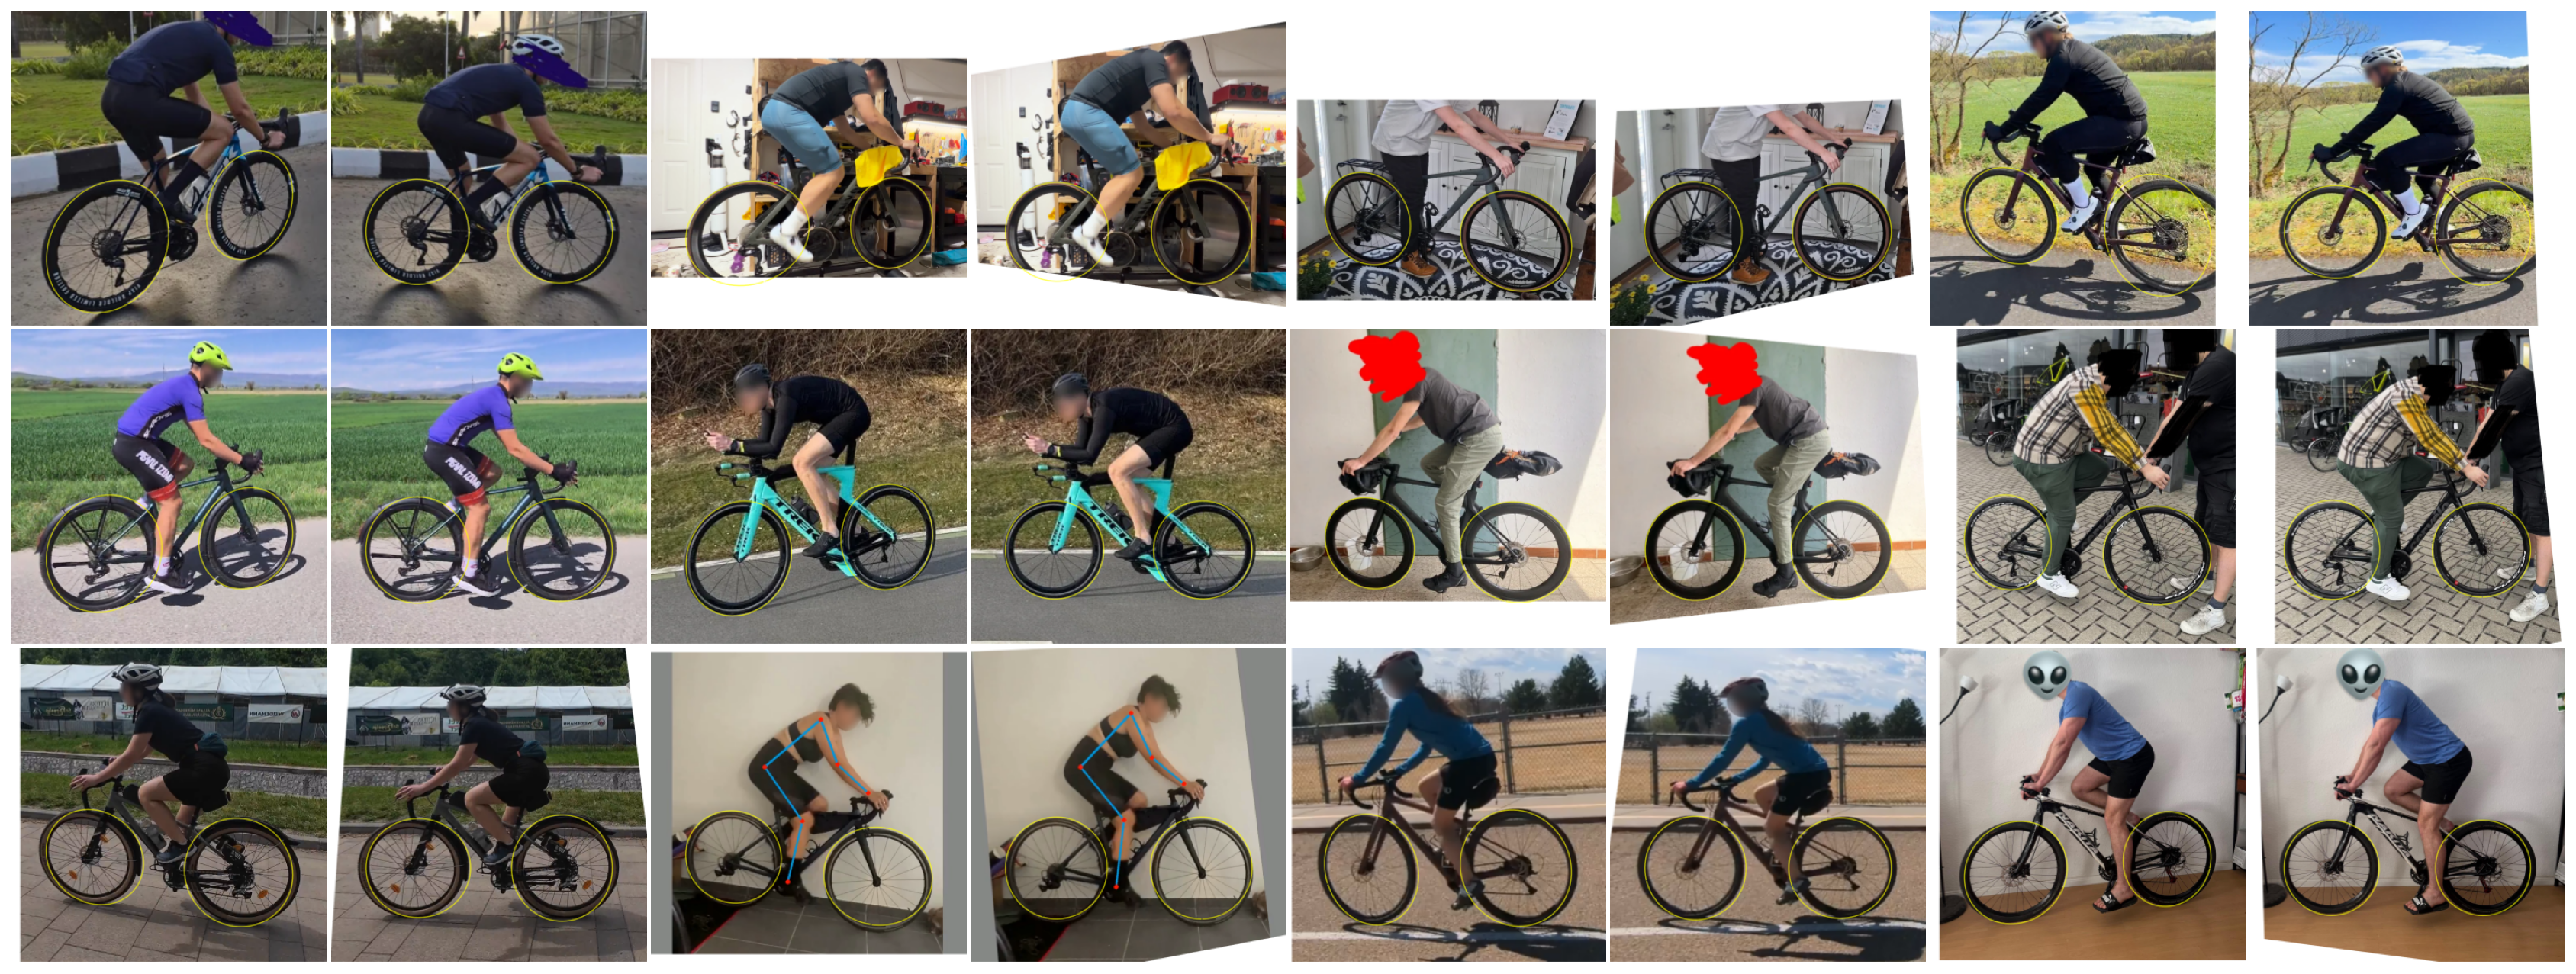

In [10]:
# Figure 2 — Top-8 Correction Pairs
ranked = sorted(
    [k for k in dist_keys if k in powell_results],
    key=lambda k: all_data[k]['L_identity'],
    reverse=True,
)[:12]

def make_wheel_thumb(img_bgr, ellipses, transform=None,
                     color='yellow', size=THUMB, fill=0.88):
    all_pts = np.vstack([
        (transform_points(sample_ellipse_points(e, 100), transform)
         if transform is not None
         else sample_ellipse_points(e, 100))
        for e in ellipses
    ])
    cx   = (all_pts[:, 0].min() + all_pts[:, 0].max()) / 2
    cy   = (all_pts[:, 1].min() + all_pts[:, 1].max()) / 2
    side = max(all_pts[:, 0].max() - all_pts[:, 0].min(),
               all_pts[:, 1].max() - all_pts[:, 1].min()) / fill
    cy  -= 0.2 * side

    h, w  = img_bgr.shape[:2]
    x0 = int(cx - side / 2); y0 = int(cy - side / 2)
    x1 = int(cx + side / 2); y1 = int(cy + side / 2)

    x0_src, y0_src = x0, y0

    pad_l = max(0, -x0); pad_t = max(0, -y0)
    pad_r = max(0, x1 - w); pad_b = max(0, y1 - h)
    if any([pad_l, pad_t, pad_r, pad_b]):
        img_bgr = cv2.copyMakeBorder(img_bgr, pad_t, pad_b, pad_l, pad_r,
                                     cv2.BORDER_CONSTANT, value=(255, 255, 255))
        x0 += pad_l; y0 += pad_t; x1 += pad_l; y1 += pad_t

    scale_x = size / (x1 - x0)
    scale_y = size / (y1 - y0)

    thumb     = cv2.resize(img_bgr[y0:y1, x0:x1], (size, size),
                           interpolation=cv2.INTER_AREA)
    thumb_rgb = cv2.cvtColor(thumb, cv2.COLOR_BGR2RGB)

    fig_tmp, ax_tmp = plt.subplots(figsize=(size/100, size/100), dpi=100)
    ax_tmp.imshow(thumb_rgb)
    ax_tmp.set_xlim(0, size); ax_tmp.set_ylim(size, 0); ax_tmp.axis('off')
    for e in ellipses:
        pts = sample_ellipse_points(e, 160)
        if transform is not None:
            pts = transform_points(pts, transform)
        ax_tmp.plot((pts[:, 0] - x0_src) * scale_x,
                    (pts[:, 1] - y0_src) * scale_y,
                    color=color, linewidth=1.1, alpha=0.6)
    fig_tmp.subplots_adjust(0, 0, 1, 1)
    fig_tmp.canvas.draw()
    buf = np.asarray(fig_tmp.canvas.buffer_rgba())[:, :, :3].copy()
    plt.close(fig_tmp)
    return cv2.resize(buf, (size, size), interpolation=cv2.INTER_AREA)

CELL   = 360
N_ROWS = 3
N_COLS = 8

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * CELL / 100, N_ROWS * CELL / 100),
    gridspec_kw={'wspace': 0.01, 'hspace': 0.01},
)

for pair_idx, key in enumerate(ranked):
    d   = all_data[key]
    cr  = powell_results[key]
    H   = build_H(cr['x'])
    corrected, H_adj = apply_homography_for_display(d['image'], H)

    row      = pair_idx // 4
    pos      = pair_idx % 4
    col_orig = pos * 2
    col_corr = pos * 2 + 1

    thumb_orig = make_wheel_thumb(d['image'], d['ellipses'],
                                  transform=None, color='yellow',
                                  size=CELL, fill=0.78)
    thumb_corr = make_wheel_thumb(corrected, d['ellipses'],
                                  transform=H_adj, color='yellow',
                                  size=CELL, fill=0.78)

    for ax, thumb in [(axes[row, col_orig], thumb_orig),
                      (axes[row, col_corr], thumb_corr)]:
        ax.imshow(thumb)
        ax.axis('off')

plt.savefig(PLOTS_DIR / 'fig_correction_pairs.pdf', bbox_inches='tight', dpi=200)
plt.show()